In [1]:
!pip install -q ultralytics kagglehub pyyaml opencv-python matplotlib scikit-learn pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.9 MB/s eta 0:00:00


In [2]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from ultralytics import YOLO
import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
GPU: Tesla T4


In [3]:
dataset_path = kagglehub.dataset_download("shlokraval/ppe-dataset-yolov8")
dataset_path = Path(dataset_path)

print("Dataset path:", dataset_path)
print("Top-level contents:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'ppe-dataset-yolov8' dataset.
Dataset path: /kaggle/input/ppe-dataset-yolov8
Top-level contents: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [4]:
#Reading yaml and print class mapping
yaml_files = list(dataset_path.rglob("*.yaml"))
print("YAML files found:")
for y in yaml_files:
    print(" -", y)

assert len(yaml_files) > 0, "No YAML file found."

data_yaml_path = yaml_files[0]
print("\nUsing YAML:", data_yaml_path)

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg.get("names", {})
if isinstance(names, list):
    class_id_to_name = {i: n for i, n in enumerate(names)}
elif isinstance(names, dict):
    class_id_to_name = {int(k): v for k, v in names.items()}
else:
    raise ValueError("Unsupported class mapping format.")

print("\nClass mapping:")
for k, v in class_id_to_name.items():
    print(k, "->", v)

YAML files found:
 - /kaggle/input/ppe-dataset-yolov8/data.yaml

Using YAML: /kaggle/input/ppe-dataset-yolov8/data.yaml

Class mapping:
0 -> Fall-Detected
1 -> Gloves
2 -> Goggles
3 -> Hardhat
4 -> Ladder
5 -> Mask
6 -> NO-Gloves
7 -> NO-Goggles
8 -> NO-Hardhat
9 -> NO-Mask
10 -> NO-Safety Vest
11 -> Person
12 -> Safety Cone
13 -> Safety Vest


In [5]:
#Selecting 5 target classes
def normalize_name(x):
    return str(x).strip().lower().replace("-", " ").replace("_", " ")

target_keywords = {
    "person": ["person", "worker", "man", "woman", "human", "people"],
    "helmet": ["helmet", "hardhat", "hard hat", "hat"],
    "vest": ["vest", "safety vest", "reflective vest", "jacket"],
    "gloves": ["glove", "gloves", "hand gloves"],
    "goggles": ["goggle", "goggles", "glasses", "safety glasses", "eye protection"]
}

selected_original_ids = {}

for cid, cname in class_id_to_name.items():
    cname_norm = normalize_name(cname)
    for target_class, keywords in target_keywords.items():
        if any(k in cname_norm for k in keywords):
            if target_class not in selected_original_ids:
                selected_original_ids[target_class] = cid

print("Selected original class IDs:")
print(selected_original_ids)

required = ["person", "helmet", "vest", "gloves", "goggles"]
missing = [c for c in required if c not in selected_original_ids]
if missing:
    raise ValueError(
        f"Could not find these required classes in dataset YAML: {missing}\n"
        "Please inspect the printed class mapping above and adjust target_keywords."
    )

old_to_new = {
    selected_original_ids["person"]: 0,
    selected_original_ids["helmet"]: 1,
    selected_original_ids["vest"]: 2,
    selected_original_ids["gloves"]: 3,
    selected_original_ids["goggles"]: 4
}

new_names = {
    0: "person",
    1: "helmet",
    2: "vest",
    3: "gloves",
    4: "goggles"
}

print("Old -> New mapping:", old_to_new)
print("New names:", new_names)

Selected original class IDs:
{'gloves': 1, 'goggles': 2, 'helmet': 3, 'vest': 10, 'person': 11}
Old -> New mapping: {11: 0, 3: 1, 10: 2, 1: 3, 2: 4}
New names: {0: 'person', 1: 'helmet', 2: 'vest', 3: 'gloves', 4: 'goggles'}


In [6]:
#Building 5 class dataset
filtered_root = Path("/content/filtered_ppe_5class")
filtered_root.mkdir(exist_ok=True)

splits_to_try = {
    "train": ["train"],
    "val": ["valid", "val"],
    "test": ["test"]
}

max_images_per_split = {
    "train": 5000,
    "val": 1000,
    "test": 1000
}

def find_existing_split(base_path, candidates):
    for c in candidates:
        img_dir = base_path / c / "images"
        lbl_dir = base_path / c / "labels"
        if img_dir.exists() and lbl_dir.exists():
            return c, img_dir, lbl_dir
    return None, None, None

summary = {}

for target_split, candidate_names in splits_to_try.items():
    src_split_name, src_img_dir, src_lbl_dir = find_existing_split(dataset_path, candidate_names)
    if src_split_name is None:
        print(f"Skipping missing split: {target_split}")
        continue

    dst_img_dir = filtered_root / target_split / "images"
    dst_lbl_dir = filtered_root / target_split / "labels"
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_files = [
        p for p in src_img_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    random.Random(SEED).shuffle(image_files)

    kept = 0
    for img_path in image_files:
        if kept >= max_images_per_split[target_split]:
            break

        label_path = src_lbl_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        filtered_lines = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(float(parts[0]))
                if cls_id in old_to_new:
                    new_cls = old_to_new[cls_id]
                    filtered_lines.append(
                        f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}"
                    )

        if len(filtered_lines) == 0:
            continue

        shutil.copy2(img_path, dst_img_dir / img_path.name)
        with open(dst_lbl_dir / f"{img_path.stem}.txt", "w") as f:
            f.write("\n".join(filtered_lines) + "\n")

        kept += 1

    summary[target_split] = kept

print("Filtered dataset summary:", summary)

Filtered dataset summary: {'train': 5000, 'val': 1000, 'test': 1000}


In [8]:
#creating data.yaml
filtered_yaml = {
    "path": str(filtered_root.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": new_names
}

yaml_path = filtered_root / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(filtered_yaml, f, sort_keys=False)

print("Saved data.yaml to:", yaml_path)

Saved data.yaml to: /content/filtered_ppe_5class/data.yaml


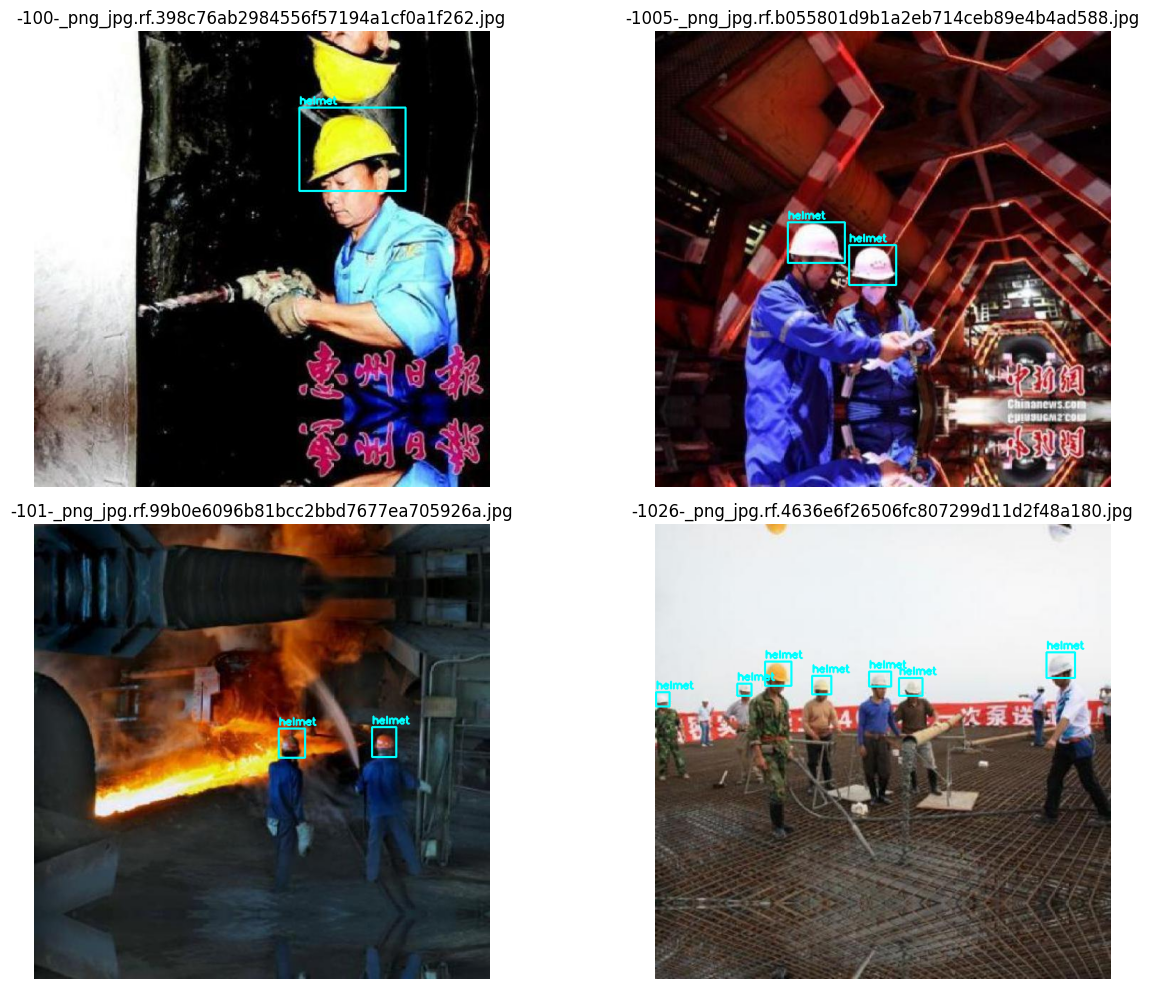

In [9]:
#Visualizing sample
def load_yolo_boxes(label_file, image_shape):
    h, w = image_shape[:2]
    boxes = []
    if not os.path.exists(label_file):
        return boxes

    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls_id, xc, yc, bw, bh = map(float, parts)
            cls_id = int(cls_id)

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

sample_train_dir = filtered_root / "train" / "images"
sample_images = sorted(list(sample_train_dir.glob("*")))[:4]

plt.figure(figsize=(14, 10))
for i, img_path in enumerate(sample_images, 1):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    label_path = filtered_root / "train" / "labels" / f"{img_path.stem}.txt"
    boxes = load_yolo_boxes(str(label_path), img.shape)

    for cls_id, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)
        cv2.putText(img, new_names[cls_id], (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
#Training YOLO
detector = YOLO("yolov8s.pt")

train_results = detector.train(
    data=str(yaml_path),
    epochs=25,
    imgsz=640,
    batch=16,
    device=DEVICE,
    workers=2,
    cache=False,
    amp=True,
    project="/content/yolo_runs",
    name="ppe_5class_final",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/filtered_ppe_5class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_5class_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [13]:
#Validating the detector
best_detector_path = Path("/content/yolo_runs/ppe_5class_final/weights/best.pt")
print("Best detector exists:", best_detector_path.exists())

detector = YOLO(str(best_detector_path))

val_metrics = detector.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    batch=8,
    device=DEVICE
)

print(val_metrics)

Best detector exists: True
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1450.7±646.4 MB/s, size: 59.7 KB)
val: Scanning /content/filtered_ppe_5class/val/labels.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 233.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 8.0it/s 15.6s
                   all       1000       2344      0.724       0.79      0.795       0.47
                person         37         50      0.812       0.94       0.95      0.724
                helmet        664       1843      0.852      0.891      0.902      0.503
                  vest         40         70      0.268      0.243      0.225       0.11
                gloves         89        191       0.84      0.921      0.932      0.471
   

In [15]:
final_model_dir = Path("/content/final_model")
final_model_dir.mkdir(exist_ok=True)

final_model_path = final_model_dir / "best.pt"
shutil.copy2(best_detector_path, final_model_path)

print("Copied best model to:", final_model_path)

from google.colab import files
files.download(str(final_model_path))

Copied best model to: /content/final_model/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>